# Conditional 3D prediction

Generate one categorical volume from the trained L-MPDD model, then improve the same latent with online critic guidance, exact decoded anchor losses, phase-fraction guidance, and final quality gates.

In [1]:
from argparse import Namespace
from pathlib import Path
import sys
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.app.api import AnchorSlice, PredictOptions
from src.app.runtime import (
    build_dataset,
    build_loader,
    load_defaults,
    load_predict_config,
    load_predictor,
)
from src.modeling.phases import quantize_phase


def take_slice(volume, axis, index):
    return np.take(volume, index, axis=axis)


## Parameters

The two center anchors are compatible at their intersection. Replace either image independently when using real multi-axis conditions.

In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"

## Predict

This is the only base-size generation path: L-MPDD latent sampling, optional critic warm-up, joint latent residual refinement, categorical Refine candidates, calibration, and selection.

In [3]:
model_runs, predict_config = load_predict_config(PREDICT_CONFIG)
model_runs = {
    name: None
    if path is None
    else Path(path) if Path(path).is_absolute() else ROOT / path
    for name, path in model_runs.items()
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**load_defaults(model_runs["vae_run_dir"] / "vae.yaml"))
args.data_dir = ROOT / args.data_dir
args.batch_size = 16

batch = next(build_loader(build_dataset(args), args, device=torch.device("cpu")))
target_images = [
    quantize_phase(image, args.num_phases).numpy()
    for image in batch[:, 0]
]
phase_counts = np.bincount(
    np.stack(target_images).reshape(-1),
    minlength=args.num_phases,
)
reference_phase_fractions = tuple((phase_counts / phase_counts.sum()).tolist())
anchor_image = target_images[0]
center_index = anchor_image.shape[0] // 2
anchors = [
    AnchorSlice(image=anchor_image, axis=0, index=center_index),
    AnchorSlice(image=anchor_image.copy(), axis=1, index=center_index),
]
if predict_config["phase_fractions"] is None:
    predict_config["phase_fractions"] = reference_phase_fractions
options = PredictOptions(
    num_phases=args.num_phases,
    **predict_config,
)

predictor = load_predictor(**model_runs, device=device)
anchor_tensor = torch.as_tensor(anchor_image, device=device).float()[None, None]
with torch.no_grad():
    anchor_mean, _ = predictor.vae.encode(anchor_tensor)
    vae_anchor = predictor.vae.decode_probs(anchor_mean).argmax(dim=1)[0]
vae_anchor_mismatch = float((vae_anchor != anchor_tensor[0, 0]).float().mean())

start_time = time.perf_counter()
volume, stats = predictor.predict(
    options,
    anchors=anchors,
    target_images=target_images,
)
elapsed_seconds = time.perf_counter() - start_time
volume_np = volume.cpu().numpy()

print("device:", device)
print(f"elapsed: {elapsed_seconds:.1f} seconds")
print("volume:", volume_np.shape, volume.dtype)
print("target images:", len(target_images))
print("reference phase fraction:", np.round(reference_phase_fractions, 4).tolist())
print("anchors:", [(anchor.axis, anchor.index) for anchor in anchors])
print("candidates:", int(stats["candidate_count"]))
print("selected latent step:", int(stats["selected_latent_step"]))
print("selected refine steps:", int(stats["selected_refine_steps"]))
print("selected latent delta/base std:", round(float(stats["selected_latent_delta_over_base_std"]), 4))
print("VAE anchor baseline:", round(vae_anchor_mismatch, 4))
print("anchor mismatches:", np.round(stats["final_anchor_mismatches"].cpu().numpy(), 4).tolist())
print("anchor phase mismatches:", np.round(stats["final_anchor_phase_mismatches"].cpu().numpy(), 4).tolist())
print("target phase fraction:", np.round(stats["final_target_phase_fraction"].cpu().numpy(), 4).tolist())
print("volume phase fraction:", np.round(stats["final_phase_fraction"].cpu().numpy(), 4).tolist())
print("quality passed:", bool(stats["quality_passed"]))
print("critic enabled:", bool(stats["critic_enabled"]))
if "joint_final_axis" in stats:
    print("final axis agreement loss:", round(float(stats["joint_final_axis"]), 4))

candidate_latent_steps = stats["candidate_latent_steps"].cpu().numpy()
candidate_refine_steps = stats["candidate_refine_steps"].cpu().numpy()
candidate_decoded = stats["candidate_decoded_anchor_mismatches"].amax(dim=1).cpu().numpy()
candidate_refined = stats["candidate_refined_anchor_mismatches"].amax(dim=1).cpu().numpy()
candidate_final = stats["candidate_final_anchor_mismatches"].amax(dim=1).cpu().numpy()
candidate_calibration = stats["candidate_calibration_changed_fractions"].cpu().numpy()
candidate_fraction_error = np.abs(
    stats["candidate_refined_phase_fraction"].cpu().numpy()
    - np.asarray(options.phase_fractions)
).max(axis=1)
candidate_pre_boundary = stats["candidate_refined_axis_global_boundary_jump"].amax(dim=1).cpu().numpy()
candidate_final_boundary = stats["candidate_final_axis_global_boundary_jump"].amax(dim=1).cpu().numpy()
print("\nlatent  refine  decoded  refined  final  fraction  calibration  boundary pre/final")
for values in zip(
    candidate_latent_steps,
    candidate_refine_steps,
    candidate_decoded,
    candidate_refined,
    candidate_final,
    candidate_fraction_error,
    candidate_calibration,
    candidate_pre_boundary,
    candidate_final_boundary,
):
    latent_step, refine_step, decoded_error, refined_error, final_error, fraction_error, changed, pre_boundary, final_boundary = values
    print(
        f"{latent_step:>6}  {refine_step:>6}  {decoded_error:>7.2%}  "
        f"{refined_error:>7.2%}  {final_error:>6.2%}  {fraction_error:>7.2%}  "
        f"{changed:>11.2%}  {pre_boundary:>7.2%}/{final_boundary:>6.2%}"
    )

Joint guidance: 100%|██████████| 700/700 [02:39<00:00,  4.38it/s, loss=1.124, anchor=0.4335, fraction=0.003978, axis=0.2024]


device: cuda
elapsed: 194.7 seconds
volume: (64, 64, 64) torch.uint8
target images: 16
reference phase fraction: [0.2867, 0.131, 0.5823]
anchors: [(0, 32), (1, 32)]
candidates: 24
selected latent step: 700
selected refine steps: 0
selected latent delta/base std: 0.569
VAE anchor baseline: 0.092
anchor mismatches: [0.11739999800920486, 0.11940000206232071]
anchor phase mismatches: [[0.08389999717473984, 0.26170000433921814, 0.09679999947547913], [0.08649999648332596, 0.22499999403953552, 0.10819999873638153]]
target phase fraction: [0.2867000102996826, 0.13099999725818634, 0.5823000073432922]
volume phase fraction: [0.2867000102996826, 0.13099999725818634, 0.5823000073432922]
quality passed: False
critic: disabled
final axis agreement loss: 0.2024

latent  refine  decoded  refined  final  fraction  calibration  boundary pre/final
     0       0   27.95%   27.95%  27.95%   15.98%       15.98%    7.08%/ 7.96%
     0       1   27.95%   27.71%  27.71%   16.97%       16.97%    6.79%/ 8.01%
 

d:\code\microlad\src\app\api\predictor.py:126: RuntimeWarning: prediction returned the least-violation candidate; inspect quality_* statistics.
  return self._predict_base(


## Quality check

Inspect anchor similarity, requested phase fractions, axis balance, repeated slices, and continuity. Anchors are optimized softly and are never copied into the output.

axis transition rate: [0.20270000398159027, 0.19990000128746033, 0.20550000667572021]
axis run-profile MAE: [0.060100000351667404, 0.06480000168085098, 0.05400000140070915]
exact repeated-slice rate: [0.0, 0.0, 0.0]
global boundary jump: [0.0625, 0.07500000298023224, 0.05909999832510948]
anchor phase recall: [[0.916100025177002, 0.7383000254631042, 0.9031999707221985], [0.9135000109672546, 0.7749999761581421, 0.8917999863624573]]
pre-calibration phase fraction: [0.26440000534057617, 0.10459999740123749, 0.6309999823570251]
calibration changed fraction: 0.0487
calibration anchor delta: [0.0, 0.0]
calibration transition delta: [0.017799999564886093, 0.01810000091791153, 0.018400000408291817]
calibration boundary delta: [0.005900000222027302, 0.005900000222027302, 0.00419999985024333]
calibration run delta: [-0.006399999838322401, -0.0052999998442828655, -0.007799999788403511]
quality gates: {'anchor mismatch within tolerance': True, 'phase fraction within tolerance': True, 'axis transiti

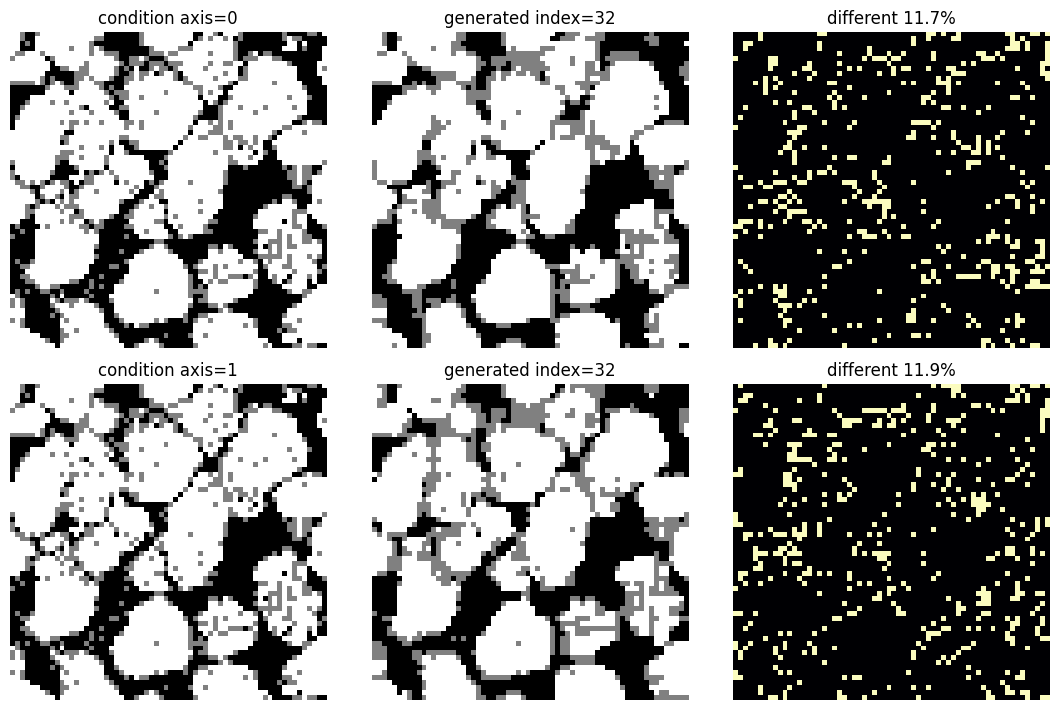

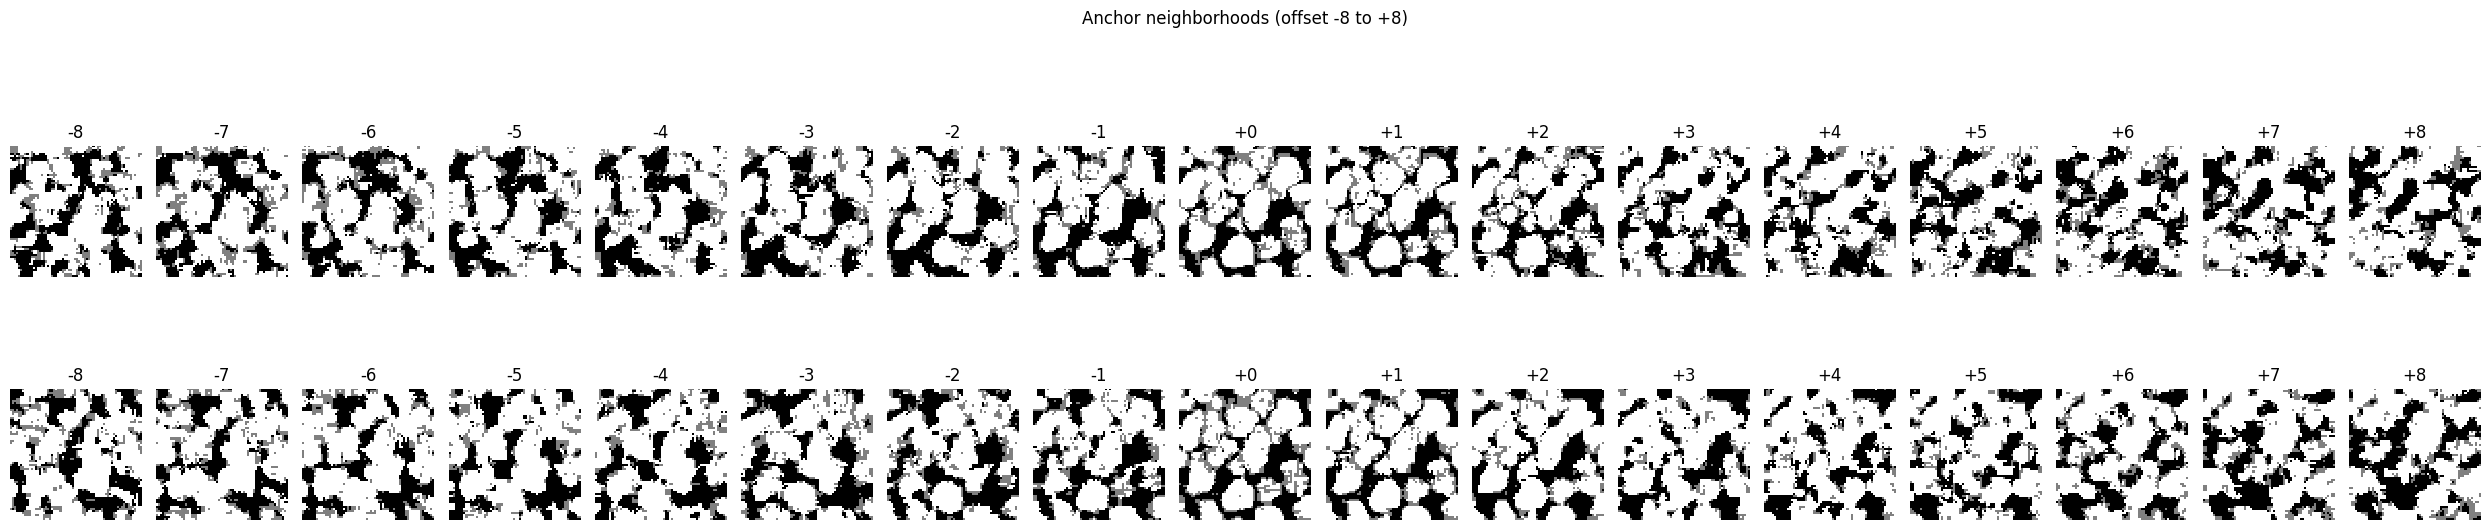

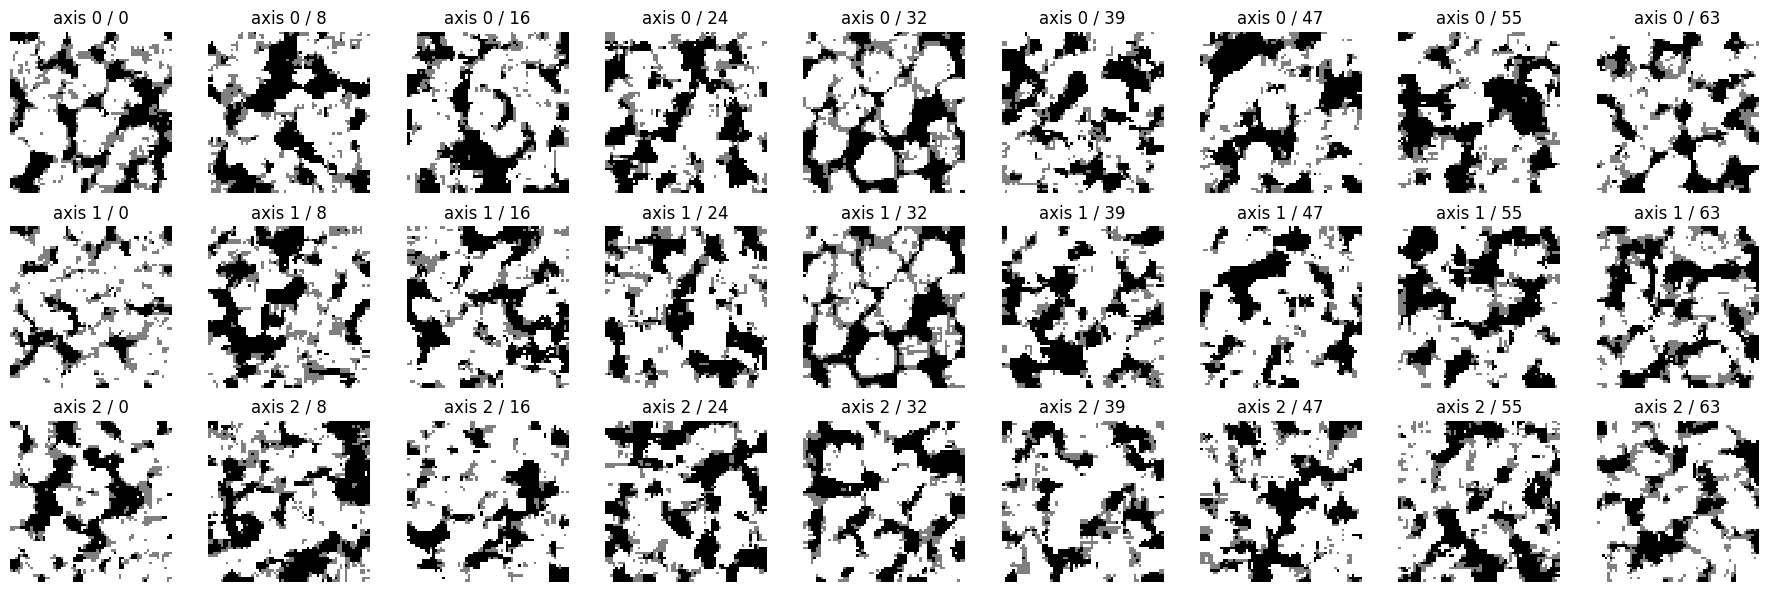

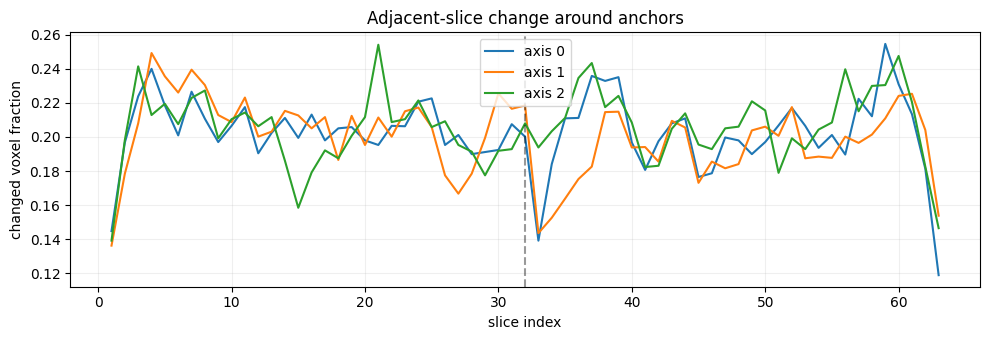

In [4]:
anchor_mismatches = stats["final_anchor_mismatches"].cpu().numpy()
anchor_phase_mismatches = stats["final_anchor_phase_mismatches"].cpu().numpy()
pre_calibration_fraction = stats["pre_calibration_phase_fraction"].cpu().numpy()
calibration_anchor_delta = stats["calibration_anchor_delta"].cpu().numpy()
calibration_transition_delta = stats["calibration_transition_delta"].cpu().numpy()
calibration_boundary_delta = stats["calibration_boundary_delta"].cpu().numpy()
calibration_run_delta = stats["calibration_run_delta"].cpu().numpy()
volume_phase_fraction = stats["final_phase_fraction"].cpu().numpy()
axis_transition_rate = stats["final_axis_transition_rate"].cpu().numpy()
axis_repeat_rate = stats["final_axis_exact_repeat_rate"].cpu().numpy()
axis_boundary_jump = stats["final_axis_global_boundary_jump"].cpu().numpy()
axis_run_mae = stats["final_axis_run_profile_mae"].cpu().numpy()

quality_gates = {
    "anchor mismatch within tolerance": bool(np.max(anchor_mismatches) <= options.quality.anchor_tolerance),
    "phase fraction within tolerance": bool(np.max(np.abs(volume_phase_fraction - options.phase_fractions)) <= options.phase_fraction_tolerance),
    "axis transition spread within tolerance": bool(np.ptp(axis_transition_rate) <= options.quality.morphology_tolerance),
    "no repeated adjacent planes": bool(np.max(axis_repeat_rate) <= options.quality.repeat_tolerance),
    "boundary jump within tolerance": bool(np.max(axis_boundary_jump) <= options.quality.continuity_tolerance),
    "run-profile error within tolerance": bool(np.max(axis_run_mae) <= options.quality.morphology_tolerance),
    "calibration change within budget": bool(float(stats["calibration_changed_fraction"]) <= options.quality.calibration_budget),
    "calibration preserves anchor labels": bool(np.all(calibration_anchor_delta == 0)),
    "anchor near VAE baseline": bool(np.max(anchor_mismatches) <= vae_anchor_mismatch + 0.02),
}

print("axis transition rate:", np.round(axis_transition_rate, 4).tolist())
print("axis run-profile MAE:", np.round(axis_run_mae, 4).tolist())
print("exact repeated-slice rate:", np.round(axis_repeat_rate, 4).tolist())
print("global boundary jump:", np.round(axis_boundary_jump, 4).tolist())
print("anchor phase recall:", np.round(1.0 - anchor_phase_mismatches, 4).tolist())
print("pre-calibration phase fraction:", np.round(pre_calibration_fraction, 4).tolist())
print("calibration changed fraction:", round(float(stats["calibration_changed_fraction"]), 4))
print("calibration anchor delta:", np.round(calibration_anchor_delta, 4).tolist())
print("calibration transition delta:", np.round(calibration_transition_delta, 4).tolist())
print("calibration boundary delta:", np.round(calibration_boundary_delta, 4).tolist())
print("calibration run delta:", np.round(calibration_run_delta, 4).tolist())
print("quality gates:", quality_gates)

fig, axes = plt.subplots(len(anchors), 3, figsize=(11, 3.6 * len(anchors)), squeeze=False)
for row, anchor in enumerate(anchors):
    generated = take_slice(volume_np, anchor.axis, anchor.index)
    difference = generated != anchor.image
    panels = [
        (anchor.image, f"condition axis={anchor.axis}", "gray", 0, args.num_phases - 1),
        (generated, f"generated index={anchor.index}", "gray", 0, args.num_phases - 1),
        (difference, f"different {anchor_mismatches[row]:.1%}", "magma", 0, 1),
    ]
    for axis, (image, title, cmap, vmin, vmax) in zip(axes[row], panels):
        axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
        axis.set_title(title)
        axis.axis("off")
plt.tight_layout()

offsets = np.arange(-8, 9)
fig, axes = plt.subplots(
    len(anchors),
    len(offsets),
    figsize=(25, 3.2 * len(anchors)),
    squeeze=False,
)
for row, anchor in enumerate(anchors):
    for column, offset in enumerate(offsets):
        index = anchor.index + int(offset)
        axes[row, column].imshow(
            take_slice(volume_np, anchor.axis, index),
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        axes[row, column].set_title(f"{offset:+d}")
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(f"axis {anchor.axis}")
fig.suptitle("Anchor neighborhoods (offset -8 to +8)")
plt.tight_layout()

indices = np.linspace(0, volume_np.shape[0] - 1, 9).round().astype(int)
fig, axes = plt.subplots(3, len(indices), figsize=(18, 6), squeeze=False)
for row, axis_id in enumerate(range(3)):
    for column, index in enumerate(indices):
        axes[row, column].imshow(
            take_slice(volume_np, axis_id, index),
            cmap="gray",
            vmin=0,
            vmax=args.num_phases - 1,
            interpolation="nearest",
        )
        axes[row, column].set_title(f"axis {axis_id} / {index}")
        axes[row, column].axis("off")
plt.tight_layout()

fig, profile_axis = plt.subplots(figsize=(10, 3.5))
for axis_id in range(3):
    adjacent_change = [
        np.mean(
            take_slice(volume_np, axis_id, index)
            != take_slice(volume_np, axis_id, index - 1)
        )
        for index in range(1, volume_np.shape[axis_id])
    ]
    profile_axis.plot(range(1, volume_np.shape[axis_id]), adjacent_change, label=f"axis {axis_id}")
for anchor_index in sorted({anchor.index for anchor in anchors}):
    profile_axis.axvline(anchor_index, color="black", linestyle="--", alpha=0.4)
profile_axis.set(
    title="Adjacent-slice change around anchors",
    xlabel="slice index",
    ylabel="changed voxel fraction",
)
profile_axis.legend()
profile_axis.grid(alpha=0.2)
plt.tight_layout()

## 3D slice browser

Choose an axis and move the slider to inspect every generated slice.

In [5]:
axis_selector = widgets.ToggleButtons(
    options=[("XY", 0), ("XZ", 1), ("YZ", 2)],
    value=0,
    description="axis",
)
index_slider = widgets.IntSlider(
    value=volume_np.shape[0] // 2,
    min=0,
    max=volume_np.shape[0] - 1,
    step=1,
    description="index",
    continuous_update=False,
)


def show_slice(axis, index):
    plt.figure(figsize=(5, 5))
    plt.imshow(
        take_slice(volume_np, axis, index),
        cmap="gray",
        vmin=0,
        vmax=args.num_phases - 1,
        interpolation="nearest",
    )
    plt.title(f"axis {axis} / index {index}")
    plt.axis("off")
    plt.show()


slice_output = widgets.interactive_output(
    show_slice,
    {"axis": axis_selector, "index": index_slider},
)
display(widgets.HBox([axis_selector, index_slider]), slice_output)


Output()